# 🚀 Entraînement Modèle NCA - Example_database_withoutrois.xlsx

## 🎯 Objectif

Entraîner le modèle NCA pour prédire `neurocog_age_flu_weight` basé sur Example_database.

**Architecture cohérente** :
```
Example_database.xlsx → Modèle NCA → neurocog_age_flu_weight
                                            ↓
                                    Modèles Risque
```

**Target** : `neurocog_age_flu_weight` (âge neurologique en années)

**Features** : 34 features (all_plus_plus)
- Démographiques : age, sex, education, language
- Cognitifs : fluency_score, moca, ravlt, logic
- Facteurs de risque : stroke, HTA, diabète, etc.

## 📦 Étape 1 : Installation des dépendances

In [ ]:
# Installer les packages nécessaires
!pip install lightgbm catboost xgboost scikit-learn pandas openpyxl joblib matplotlib seaborn -q

## 📚 Étape 2 : Imports

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import lightgbm as lgb
import catboost as cb
from xgboost import XGBRegressor
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

# Configuration matplotlib
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

print("✅ Imports réussis !")

✅ Imports réussis !


## 🎯 Étape 3 : Configuration des Features

In [5]:
# VERSION BASIC (7 features - minimum viable)
FEATURES_BASIC = [
    'age',
    'sex',
    'education',
    'language',
    'fluency_score',
    'moca',
    'ravlt_imm',
]

# VERSION ALL (16 features - tous les scores cognitifs)
FEATURES_ALL = FEATURES_BASIC + [
    'handedness',
    'nb_language',
    'hearing',
    'ravlt_delay',
    'logic_imm',
    'logic_delay',
]

# VERSION ALL_PLUS_PLUS (34 features - facteurs de risque complets)
FEATURES_ALL_PLUS_PLUS = FEATURES_ALL + [
    'hist_demence_fam',
    'hist_demence_parent',
    'living_alone',
    'income',
    'retired',
    'stroke',
    'tbi',
    'hta',
    'diab_type2',
    'obesity',
    'depression',
    'anxiety',
    'smoking',
    'alcohol',
    'poly_pharm5',
    'physical_activity',
    'social_life',
    'cognitive_activities',
    'nutrition_score',
    'sleep_deprivation',
]

# Target
TARGET = 'neurocog_age_flu_weight'

print(f"📋 Features configurées :")
print(f"   BASIC : {len(FEATURES_BASIC)} features")
print(f"   ALL : {len(FEATURES_ALL)} features")
print(f"   ALL_PLUS_PLUS : {len(FEATURES_ALL_PLUS_PLUS)} features")
print(f"\n🎯 Target : {TARGET}")

📋 Features configurées :
   BASIC : 7 features
   ALL : 13 features
   ALL_PLUS_PLUS : 33 features

🎯 Target : neurocog_age_flu_weight


## 📂 Étape 4 : Chargement des données

⚠️ **IMPORTANT** : Uploadez `Example_database_withoutrois.xlsx` dans le même dossier que ce notebook.

In [10]:
# Charger le fichier
DATA_PATH = '../../Example_database_withoutrois.xlsx'

print(f"📂 Chargement : {DATA_PATH}")
df = pd.read_excel(DATA_PATH)

print(f"\n✅ Données chargées :")
print(f"   Lignes : {len(df)}")
print(f"   Colonnes : {len(df.columns)}")

# Afficher les premières lignes
df.head()

📂 Chargement : ../../Example_database_withoutrois.xlsx

✅ Données chargées :
   Lignes : 1119
   Colonnes : 50


,Identifiers,age,sex,education,education_group,language,fluency_score,handedness,nb_language,hearing,...,anxiety_score,smoking,alcohol,poly_pharm5,poly_pharm10,physical_activity,social_life,cognitive_activities,nutrition_score,sleep_deprivation
0,4509950,70.3,1.0,21.0,4.0,1.0,18.0,0.0,2,0.0,...,6.0,0.0,1.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0
1,7424803,78.4,1.0,14.0,2.0,1.0,19.0,0.0,2,1.0,...,0.0,0.0,1.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0
2,7874568,74.5,0.0,18.0,4.0,1.0,17.0,0.0,2,0.0,...,3.0,0.0,0.0,NaN,NaN,0.0,1.0,0.0,0.0,1.0
3,3865361,73.3,1.0,14.0,2.0,1.0,17.0,0.0,2,0.0,...,4.0,0.0,1.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0
4,6841569,73.8,1.0,15.0,3.0,1.0,24.0,0.0,1,0.0,...,0.0,0.0,1.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0


## 🔍 Étape 5 : Exploration des données

✅ Target 'neurocog_age_flu_weight' trouvée !

📊 Statistiques de neurocog_age_flu_weight :
count    1060.000000
mean       74.624741
std        11.499712
min        45.616701
25%        65.944965
50%        74.381001
75%        82.939430
max       104.935177
Name: neurocog_age_flu_weight, dtype: float64


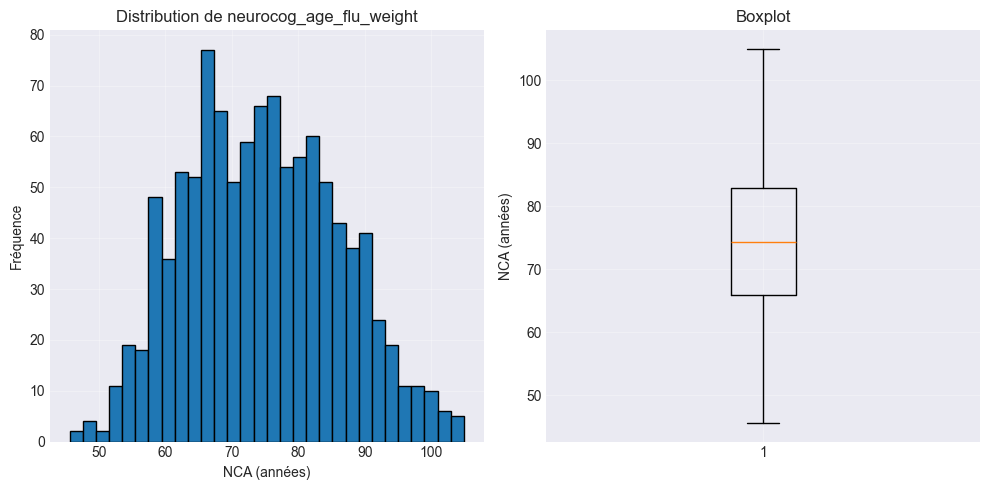

In [11]:
# Vérifier que la target existe
if TARGET in df.columns:
    print(f"✅ Target '{TARGET}' trouvée !")
    print(f"\n📊 Statistiques de {TARGET} :")
    print(df[TARGET].describe())
    
    # Distribution de la target
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.hist(df[TARGET].dropna(), bins=30, edgecolor='black')
    plt.xlabel('NCA (années)')
    plt.ylabel('Fréquence')
    plt.title(f'Distribution de {TARGET}')
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 2, 2)
    plt.boxplot(df[TARGET].dropna())
    plt.ylabel('NCA (années)')
    plt.title('Boxplot')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print(f"❌ Target '{TARGET}' non trouvée !")
    print(f"\nColonnes disponibles : {list(df.columns)}")

In [13]:
# Vérifier les colonnes nécessaires
print("🔍 Vérification des features ALL_PLUS_PLUS :")
print("-" * 60)

missing_cols = []
for col in FEATURES_ALL_PLUS_PLUS:
    if col in df.columns:
        print(f"   ✅ {col}")
    else:
        print(f"   ❌ {col} → MANQUANTE")
        missing_cols.append(col)

if missing_cols:
    print(f"\n⚠️  {len(missing_cols)} colonnes manquantes : {missing_cols}")
else:
    print("\n✅ Toutes les colonnes sont présentes !")

🔍 Vérification des features ALL_PLUS_PLUS :
------------------------------------------------------------
   ✅ age
   ✅ sex
   ✅ education
   ✅ language
   ✅ fluency_score
   ✅ moca
   ✅ ravlt_imm
   ✅ handedness
   ✅ nb_language
   ✅ hearing
   ✅ ravlt_delay
   ✅ logic_imm
   ✅ logic_delay
   ✅ hist_demence_fam
   ✅ hist_demence_parent
   ✅ living_alone
   ✅ income
   ✅ retired
   ✅ stroke
   ✅ tbi
   ✅ hta
   ✅ diab_type2
   ✅ obesity
   ✅ depression
   ✅ anxiety
   ✅ smoking
   ✅ alcohol
   ✅ poly_pharm5
   ✅ physical_activity
   ✅ social_life
   ✅ cognitive_activities
   ✅ nutrition_score
   ✅ sleep_deprivation

✅ Toutes les colonnes sont présentes !


## 🧹 Étape 6 : Préparation des données

In [14]:
# On va utiliser ALL_PLUS_PLUS (meilleure version)
FEATURES = FEATURES_ALL_PLUS_PLUS

# Sélectionner les colonnes
required_cols = FEATURES + [TARGET]
df_subset = df[required_cols].copy()

print(f"📊 Données avant nettoyage : {len(df_subset)} lignes")

# Supprimer les lignes avec valeurs manquantes
df_clean = df_subset.dropna()

print(f"📊 Données après nettoyage : {len(df_clean)} lignes")
print(f"   Lignes supprimées : {len(df_subset) - len(df_clean)}")

# Séparer X et y
X = df_clean[FEATURES]
y = df_clean[TARGET]

print(f"\n✅ Données prêtes :")
print(f"   X : {X.shape}")
print(f"   y : {y.shape}")

📊 Données avant nettoyage : 1119 lignes
📊 Données après nettoyage : 668 lignes
   Lignes supprimées : 451

✅ Données prêtes :
   X : (668, 33)
   y : (668,)


## ✂️ Étape 7 : Train/Test Split

In [15]:
# Split 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"📊 Split réalisé :")
print(f"   Train : {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"   Test : {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")

📊 Split réalisé :
   Train : 534 (79.9%)
   Test : 134 (20.1%)


## 🤖 Étape 8 : Entraînement des modèles

On va entraîner 3 algorithmes :
1. **LightGBM** (rapide, performant)
2. **CatBoost** (robuste)
3. **XGBoost** (classique)

### 8.1 - LightGBM

In [16]:
print("🤖 Entraînement : LightGBM")
print("-" * 60)

# Créer et entraîner le modèle
lgbm_model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    random_state=42,
    verbose=-1
)

lgbm_model.fit(X_train, y_train)

# Prédictions
y_pred_train_lgbm = lgbm_model.predict(X_train)
y_pred_test_lgbm = lgbm_model.predict(X_test)

# Métriques Train
print("\n📊 TRAIN :")
mae_train = mean_absolute_error(y_train, y_pred_train_lgbm)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train_lgbm))
r2_train = r2_score(y_train, y_pred_train_lgbm)
print(f"   MAE  : {mae_train:.3f} ans")
print(f"   RMSE : {rmse_train:.3f} ans")
print(f"   R²   : {r2_train:.3f}")

# Métriques Test
print("\n📊 TEST :")
mae_test_lgbm = mean_absolute_error(y_test, y_pred_test_lgbm)
rmse_test_lgbm = np.sqrt(mean_squared_error(y_test, y_pred_test_lgbm))
r2_test_lgbm = r2_score(y_test, y_pred_test_lgbm)
print(f"   MAE  : {mae_test_lgbm:.3f} ans")
print(f"   RMSE : {rmse_test_lgbm:.3f} ans")
print(f"   R²   : {r2_test_lgbm:.3f}")

# Cross-validation
print("\n🔄 Cross-validation (5-fold) :")
cv_scores = cross_val_score(lgbm_model, X_train, y_train, 
                            cv=5, scoring='neg_mean_absolute_error')
cv_mae_lgbm = -cv_scores.mean()
cv_std_lgbm = cv_scores.std()
print(f"   CV MAE : {cv_mae_lgbm:.3f} ± {cv_std_lgbm:.3f} ans")

print("\n✅ LightGBM entraîné !")

🤖 Entraînement : LightGBM
------------------------------------------------------------

📊 TRAIN :
   MAE  : 0.291 ans
   RMSE : 0.373 ans
   R²   : 0.999

📊 TEST :
   MAE  : 2.574 ans
   RMSE : 3.371 ans
   R²   : 0.886

🔄 Cross-validation (5-fold) :
   CV MAE : 2.896 ± 0.178 ans

✅ LightGBM entraîné !


### 8.2 - CatBoost

In [17]:
print("🤖 Entraînement : CatBoost")
print("-" * 60)

# Créer et entraîner le modèle
catboost_model = cb.CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    random_state=42,
    verbose=False
)

catboost_model.fit(X_train, y_train)

# Prédictions
y_pred_train_cat = catboost_model.predict(X_train)
y_pred_test_cat = catboost_model.predict(X_test)

# Métriques Test
print("\n📊 TEST :")
mae_test_cat = mean_absolute_error(y_test, y_pred_test_cat)
rmse_test_cat = np.sqrt(mean_squared_error(y_test, y_pred_test_cat))
r2_test_cat = r2_score(y_test, y_pred_test_cat)
print(f"   MAE  : {mae_test_cat:.3f} ans")
print(f"   RMSE : {rmse_test_cat:.3f} ans")
print(f"   R²   : {r2_test_cat:.3f}")

# Cross-validation
print("\n🔄 Cross-validation (5-fold) :")
cv_scores = cross_val_score(catboost_model, X_train, y_train, 
                            cv=5, scoring='neg_mean_absolute_error')
cv_mae_cat = -cv_scores.mean()
cv_std_cat = cv_scores.std()
print(f"   CV MAE : {cv_mae_cat:.3f} ± {cv_std_cat:.3f} ans")

print("\n✅ CatBoost entraîné !")

🤖 Entraînement : CatBoost
------------------------------------------------------------

📊 TEST :
   MAE  : 2.197 ans
   RMSE : 2.968 ans
   R²   : 0.911

🔄 Cross-validation (5-fold) :
   CV MAE : 2.697 ± 0.142 ans

✅ CatBoost entraîné !


### 8.3 - XGBoost

In [18]:
print("🤖 Entraînement : XGBoost")
print("-" * 60)

# Créer et entraîner le modèle
xgb_model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    verbosity=0
)

xgb_model.fit(X_train, y_train)

# Prédictions
y_pred_train_xgb = xgb_model.predict(X_train)
y_pred_test_xgb = xgb_model.predict(X_test)

# Métriques Test
print("\n📊 TEST :")
mae_test_xgb = mean_absolute_error(y_test, y_pred_test_xgb)
rmse_test_xgb = np.sqrt(mean_squared_error(y_test, y_pred_test_xgb))
r2_test_xgb = r2_score(y_test, y_pred_test_xgb)
print(f"   MAE  : {mae_test_xgb:.3f} ans")
print(f"   RMSE : {rmse_test_xgb:.3f} ans")
print(f"   R²   : {r2_test_xgb:.3f}")

# Cross-validation
print("\n🔄 Cross-validation (5-fold) :")
cv_scores = cross_val_score(xgb_model, X_train, y_train, 
                            cv=5, scoring='neg_mean_absolute_error')
cv_mae_xgb = -cv_scores.mean()
cv_std_xgb = cv_scores.std()
print(f"   CV MAE : {cv_mae_xgb:.3f} ± {cv_std_xgb:.3f} ans")

print("\n✅ XGBoost entraîné !")

🤖 Entraînement : XGBoost
------------------------------------------------------------

📊 TEST :
   MAE  : 2.602 ans
   RMSE : 3.391 ans
   R²   : 0.884

🔄 Cross-validation (5-fold) :
   CV MAE : 2.854 ± 0.113 ans

✅ XGBoost entraîné !


## 📊 Étape 9 : Comparaison des modèles

In [19]:
# Créer DataFrame comparatif
results = pd.DataFrame({
    'Modèle': ['LightGBM', 'CatBoost', 'XGBoost'],
    'Test MAE': [mae_test_lgbm, mae_test_cat, mae_test_xgb],
    'Test R²': [r2_test_lgbm, r2_test_cat, r2_test_xgb],
    'CV MAE': [cv_mae_lgbm, cv_mae_cat, cv_mae_xgb],
    'CV STD': [cv_std_lgbm, cv_std_cat, cv_std_xgb]
})

results = results.sort_values('Test MAE')

print("="*80)
print("📊 RÉSUMÉ DES PERFORMANCES")
print("="*80)
print(results.to_string(index=False))

# Meilleur modèle
best = results.iloc[0]
print(f"\n🥇 MEILLEUR MODÈLE : {best['Modèle']}")
print(f"   Test MAE : {best['Test MAE']:.3f} ans")
print(f"   Test R²  : {best['Test R²']:.3f}")
print(f"   CV MAE   : {best['CV MAE']:.3f} ± {best['CV STD']:.3f} ans")

📊 RÉSUMÉ DES PERFORMANCES
  Modèle  Test MAE  Test R²   CV MAE   CV STD
CatBoost  2.197033 0.911277 2.696739 0.142347
LightGBM  2.573665 0.885597 2.895506 0.178373
 XGBoost  2.602225 0.884234 2.854353 0.112869

🥇 MEILLEUR MODÈLE : CatBoost
   Test MAE : 2.197 ans
   Test R²  : 0.911
   CV MAE   : 2.697 ± 0.142 ans


## 📈 Étape 10 : Visualisations

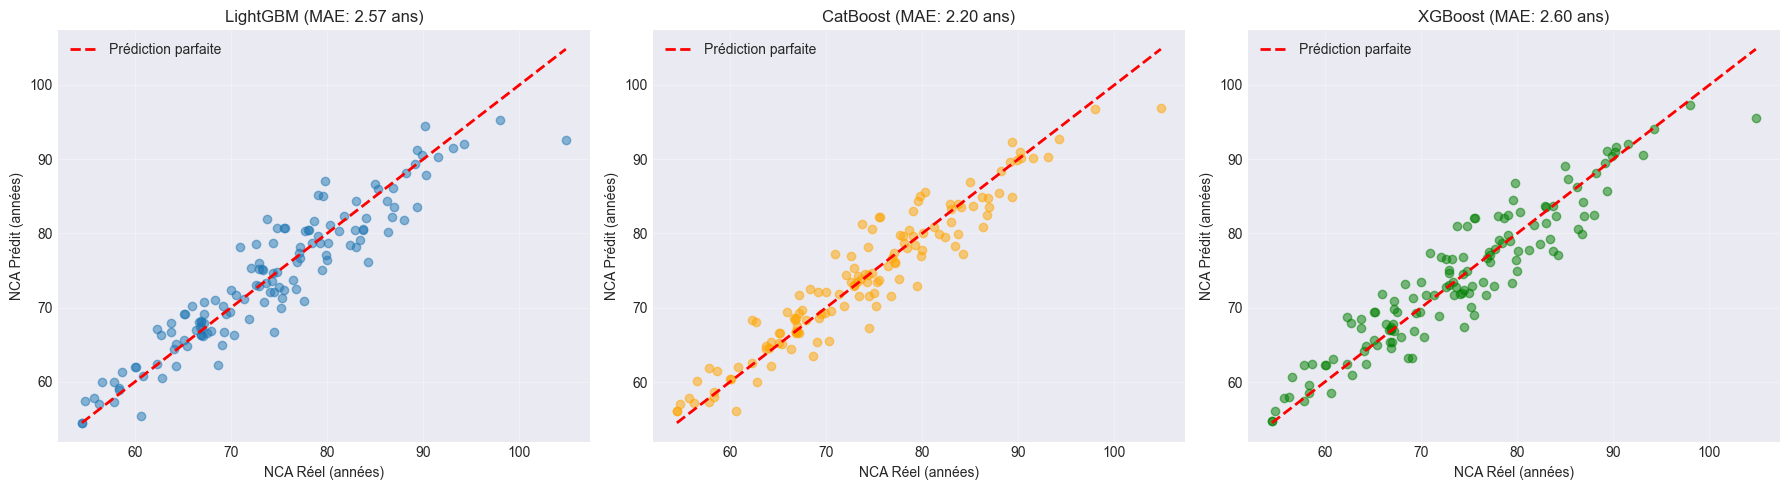

In [20]:
# Graphique de comparaison des prédictions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# LightGBM
axes[0].scatter(y_test, y_pred_test_lgbm, alpha=0.5)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', lw=2, label='Prédiction parfaite')
axes[0].set_xlabel('NCA Réel (années)')
axes[0].set_ylabel('NCA Prédit (années)')
axes[0].set_title(f'LightGBM (MAE: {mae_test_lgbm:.2f} ans)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# CatBoost
axes[1].scatter(y_test, y_pred_test_cat, alpha=0.5, color='orange')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', lw=2, label='Prédiction parfaite')
axes[1].set_xlabel('NCA Réel (années)')
axes[1].set_ylabel('NCA Prédit (années)')
axes[1].set_title(f'CatBoost (MAE: {mae_test_cat:.2f} ans)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# XGBoost
axes[2].scatter(y_test, y_pred_test_xgb, alpha=0.5, color='green')
axes[2].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', lw=2, label='Prédiction parfaite')
axes[2].set_xlabel('NCA Réel (années)')
axes[2].set_ylabel('NCA Prédit (années)')
axes[2].set_title(f'XGBoost (MAE: {mae_test_xgb:.2f} ans)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

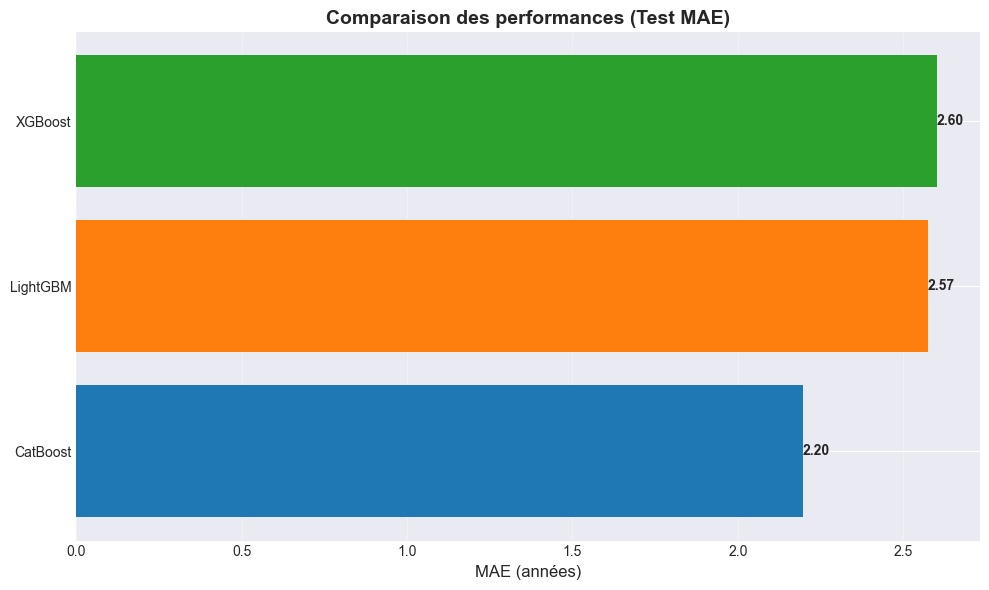

In [21]:
# Graphique comparatif des MAE
fig, ax = plt.subplots(figsize=(10, 6))

models = results['Modèle'].tolist()
mae_values = results['Test MAE'].tolist()
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

bars = ax.barh(models, mae_values, color=colors)
ax.set_xlabel('MAE (années)', fontsize=12)
ax.set_title('Comparaison des performances (Test MAE)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# Ajouter les valeurs sur les barres
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2, 
            f'{mae_values[i]:.2f}', 
            ha='left', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 🔍 Étape 11 : Feature Importance (Meilleur modèle)

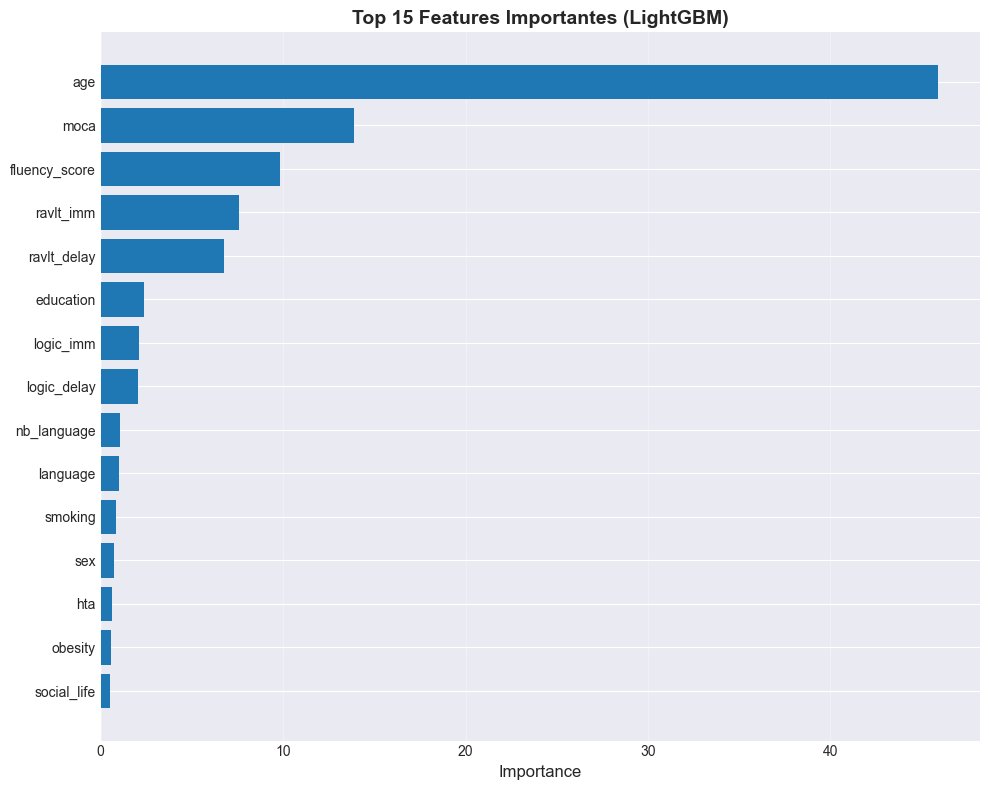


📊 Top 15 Features :
      Feature  Importance
          age   45.907685
         moca   13.872778
fluency_score    9.828570
    ravlt_imm    7.598885
  ravlt_delay    6.768128
    education    2.363371
    logic_imm    2.114369
  logic_delay    2.021415
  nb_language    1.054764
     language    0.995809
      smoking    0.837443
          sex    0.710338
          hta    0.594576
      obesity    0.584022
  social_life    0.518236


In [25]:
# On prend le meilleur modèle (supposons LightGBM)
best_model = catboost_model

# Extraire les importances
importances = best_model.feature_importances_
feature_names = FEATURES

# Créer DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

# Top 15 features
top_15 = importance_df.head(15)

# Plot
plt.figure(figsize=(10, 8))
plt.barh(range(len(top_15)), top_15['Importance'])
plt.yticks(range(len(top_15)), top_15['Feature'])
plt.xlabel('Importance', fontsize=12)
plt.title('Top 15 Features Importantes (LightGBM)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("\n📊 Top 15 Features :")
print(top_15.to_string(index=False))

## 💾 Étape 12 : Sauvegarder les modèles

In [26]:
# Créer le dossier de sortie
OUTPUT_DIR = "nca_models_example_db"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Sauvegarder les 3 modèles
joblib.dump(lgbm_model, os.path.join(OUTPUT_DIR, "LGBM_all_plus_plus.sav"))
joblib.dump(catboost_model, os.path.join(OUTPUT_DIR, "CATBOOST_all_plus_plus.sav"))
joblib.dump(xgb_model, os.path.join(OUTPUT_DIR, "XGBOOST_all_plus_plus.sav"))

# Sauvegarder les résultats
results.to_csv(os.path.join(OUTPUT_DIR, "training_results.csv"), index=False)

print("✅ Modèles sauvegardés dans :")
print(f"   📁 {OUTPUT_DIR}/")
print(f"   - LGBM_all_plus_plus.sav")
print(f"   - CATBOOST_all_plus_plus.sav")
print(f"   - XGBOOST_all_plus_plus.sav")
print(f"   - training_results.csv")

✅ Modèles sauvegardés dans :
   📁 nca_models_example_db/
   - LGBM_all_plus_plus.sav
   - CATBOOST_all_plus_plus.sav
   - XGBOOST_all_plus_plus.sav
   - training_results.csv


## 🧪 Étape 13 : Test avec un patient exemple

In [24]:
# Patient exemple (à adapter selon vos données)
patient_exemple = {
    'age': 68,
    'sex': 0,  # 0=Femme, 1=Homme
    'education': 12,
    'language': 1,
    'fluency_score': 45,
    'moca': 24,
    'ravlt_imm': 8,
    'handedness': 1,
    'nb_language': 2,
    'hearing': 0,
    'ravlt_delay': 6,
    'logic_imm': 12,
    'logic_delay': 10,
    'hist_demence_fam': 1,
    'hist_demence_parent': 0,
    'living_alone': 0,
    'income': 50000,
    'retired': 1,
    'stroke': 0,
    'tbi': 0,
    'hta': 1,
    'diab_type2': 0,
    'obesity': 0,
    'depression': 0,
    'anxiety': 0,
    'smoking': 0,
    'alcohol': 1,
    'poly_pharm5': 0,
    'physical_activity': 3,
    'social_life': 4,
    'cognitive_activities': 3,
    'nutrition_score': 6,
    'sleep_deprivation': 0,
}

# Créer DataFrame avec les features dans le bon ordre
patient_df = pd.DataFrame([patient_exemple])[FEATURES]

# Prédire avec le meilleur modèle
nca_predicted = lgbm_model.predict(patient_df)[0]
delta_nca = nca_predicted - patient_exemple['age']

print("="*80)
print("🧪 TEST PATIENT EXEMPLE")
print("="*80)
print(f"\n👤 Patient : {'Femme' if patient_exemple['sex']==0 else 'Homme'}, {patient_exemple['age']} ans")
print(f"\n🎯 RÉSULTATS :")
print(f"   NCA prédit : {nca_predicted:.1f} ans")
print(f"   Delta NCA  : {delta_nca:+.1f} ans")

if delta_nca > 0:
    print(f"\n⚠️  Le cerveau de ce patient est {delta_nca:.1f} ans PLUS ÂGÉ que son âge chronologique")
else:
    print(f"\n✅ Le cerveau de ce patient est {abs(delta_nca):.1f} ans PLUS JEUNE que son âge chronologique")

🧪 TEST PATIENT EXEMPLE

👤 Patient : Femme, 68 ans

🎯 RÉSULTATS :
   NCA prédit : 71.9 ans
   Delta NCA  : +3.9 ans

⚠️  Le cerveau de ce patient est 3.9 ans PLUS ÂGÉ que son âge chronologique


## 🎯 Prochaines étapes

1. ✅ **Modèle NCA entraîné** → `LGBM_all_plus_plus.sav`
2. 🔄 **Entraîner risk_dementia** sur le même fichier (déjà fait dans les notebooks)
3. 🔄 **Entraîner risk_handicap** sur le même fichier (déjà fait dans les notebooks)
4. 🔗 **Intégrer dans l'API Django** :
   - Charger les 3 modèles
   - Prédire NCA
   - Utiliser NCA pour prédire risques
5. 🧪 **Tester avec patients réels**

---

**FÉLICITATIONS ! 🎉** Votre modèle NCA est prêt !